# ResNet-50 Multilabel UCMerced — Stratified vs Random Split

## Hipótesis
Los modelos ResNet-50 pre-entrenados en ImageNet son suficientemente robustos al desbalance de clases como para **no** degradarse significativamente cuando el split train/val es aleatorio en lugar de estratificado.
- **H0 (hipótesis verdadera):** Δ métricas entre ambos modelos < 2 pp → el pre-entrenamiento compensa el desbalance.
- **H1 (hipótesis falsa):** Δ métricas ≥ 2 pp → el split estratificado sigue siendo necesario.

Ambos modelos son ResNet-50 idénticos (misma seed, mismos pesos iniciales), solo difiere el tipo de split de train/val.

## 1. Setup — Drive, dependencias y repo

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/DL_Group_MGI1"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working in:", os.getcwd())

!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image wandb iterative-stratification torchmetrics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working in: /content/drive/MyDrive/DL_Group_MGI1


In [11]:
# Run this everytime you update something in the repo\!
REPO = "https://github.com/gabrielcastrob/Deep_learning_WUR"

if not os.listdir(PROJECT_DIR):
    !git clone {REPO} {PROJECT_DIR}
else:
    !git -C {PROJECT_DIR} pull

%cd {PROJECT_DIR}
print("Working in:", os.getcwd())

Already up to date.
/content
Working in: /content/drive/MyDrive/DL_Group_MGI1


## 2. Descarga del dataset UCMerced

In [12]:
import zipfile, subprocess, shutil

if not os.path.exists('ucmdata'):
    print("Cloning ucmdata repo and extracting images...")
    subprocess.run(['git', 'clone', 'https://git.wur.nl/lobry001/ucmdata.git'])
    os.chdir('ucmdata')
    with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zf:
        zf.extractall('UCMImages')
    shutil.move('UCMImages/UCMerced_LandUse/Images', '.')
    shutil.rmtree('UCMImages')
    os.remove('README.md')
    os.remove('UCMerced_LandUse.zip')
    os.chdir(PROJECT_DIR)
    print("Dataset ready.")
else:
    print("Dataset already present.")

Dataset already present.


## 3. Importaciones

In [13]:
import importlib
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tvm
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import utils
importlib.reload(utils)
from utils import (
    build_dataloaders,
    LightningModuleMultilabel,
    compute_test_metrics,
    append_metrics_to_csv,
    plot_training_curves,
    plot_per_class_metrics,
    plot_exact_match_by_class_count,
)

L.seed_everything(42, workers=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
Path("outputs/checkpoints").mkdir(parents=True, exist_ok=True)
Path("outputs/logs").mkdir(parents=True, exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("outputs/predictions").mkdir(parents=True, exist_ok=True)
print("Accelerator:", DEVICE)
if DEVICE == "gpu":
    print("GPU:", torch.cuda.get_device_name(0))

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Accelerator: gpu
GPU: Tesla T4


## 4. Hiperparámetros

In [ ]:
PRETRAINED_MODEL      = "resnet50"
MAX_EPOCHS            = 25
EARLYSTOPPING_EPOCHS  = 7
LR                    = 1e-4
WEIGHT_DECAY          = 1e-5
THRESHOLD             = 0.5
SEED                  = 42
BATCH_SIZE            = 32
NUM_WORKERS           = 2

print(f"Model:        {PRETRAINED_MODEL}")
print(f"Max epochs:   {MAX_EPOCHS}  |  Early stopping: {EARLYSTOPPING_EPOCHS}")
print(f"LR:           {LR}  |  Weight decay: {WEIGHT_DECAY}")
print(f"Batch size:   {BATCH_SIZE}  |  Threshold: {THRESHOLD}")

Model:        resnet50
Max epochs:   25  |  Early stopping: 5
LR:           0.0001  |  Weight decay: 1e-05
Batch size:   32  |  Threshold: 0.5


## 5. Dataloaders — Modelo A (Stratified) y Modelo B (Random)

Se construyen dos sets de dataloaders con `build_dataloaders()` desde `utils.py`.
El argumento `stratified` controla el tipo de split:
- `stratified=True` → `MultilabelStratifiedShuffleSplit` (preserva distribución de clases)
- `stratified=False` → shuffle aleatorio con la misma seed

In [15]:
# Modelo A: Stratified split
print("=" * 55)
print("  DATALOADER A - STRATIFIED SPLIT")
print("=" * 55)

train_loader_A, val_loader_A, test_loader_A, classes, pos_w_A = build_dataloaders(
    root_dir    = "ucmdata",
    label_file  = "LandUse_Multilabeled.txt",
    image_size  = (224, 224),
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    val_frac    = 0.15,
    test_frac   = 0.15,
    seed        = SEED,
    image_ext   = ".tif",
    stratified  = True,
)
NUM_CLASSES = len(classes)
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_loader_A.dataset)} | Val: {len(val_loader_A.dataset)} | Test: {len(test_loader_A.dataset)}")

  DATALOADER A - STRATIFIED SPLIT
Classes: 17
Train: 1469 | Val: 317 | Test: 314


In [16]:
# Modelo B: Random split
print("=" * 55)
print("  DATALOADER B - RANDOM SPLIT")
print("=" * 55)

train_loader_B, val_loader_B, test_loader_B, _, pos_w_B = build_dataloaders(
    root_dir    = "ucmdata",
    label_file  = "LandUse_Multilabeled.txt",
    image_size  = (224, 224),
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    val_frac    = 0.15,
    test_frac   = 0.15,
    seed        = SEED,
    image_ext   = ".tif",
    stratified  = False,
)
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_loader_B.dataset)} | Val: {len(val_loader_B.dataset)} | Test: {len(test_loader_B.dataset)}")

  DATALOADER B - RANDOM SPLIT
Classes: 17
Train: 1470 | Val: 315 | Test: 315


## 6. Arquitectura ResNet-50

Se reemplaza la capa fully connected (`model.fc`) por una nueva `Linear(2048 → 17)`.
Todos los pesos permanecen entrenables (fine-tuning completo).

In [17]:
def build_resnet50(num_classes: int):
    """ResNet-50 pre-trained on ImageNet with new multilabel classification head."""
    weights = tvm.ResNet50_Weights.IMAGENET1K_V2
    model   = tvm.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

_tmp = build_resnet50(NUM_CLASSES)
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"ResNet-50  |  Trainable params: {n_params:,}  |  Output logits: {NUM_CLASSES}")
del _tmp

ResNet-50  |  Trainable params: 23,542,865  |  Output logits: 17


## 7. Entrenamiento — Modelo A (Stratified Split)

In [ ]:
print("=" * 55)
print("  MODELO A - STRATIFIED SPLIT")
print("=" * 55)

L.seed_everything(SEED, workers=True)

backbone_A = build_resnet50(NUM_CLASSES)
lit_A = LightningModuleMultilabel(
    model        = backbone_A,
    num_classes  = NUM_CLASSES,
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    max_epochs   = MAX_EPOCHS,
    threshold    = THRESHOLD,
    pos_weight   = pos_w_A,
)

ckpt_A = ModelCheckpoint(
    dirpath  = "outputs/checkpoints",
    filename = "resnetA_stratified-best-{epoch:02d}-{val_f1:.4f}",
    monitor  = "val_f1", mode="max", save_top_k=1, save_weights_only=True,
)
early_A = EarlyStopping(
    monitor  = "val_loss", mode="min",
    patience = EARLYSTOPPING_EPOCHS, min_delta=1e-3, verbose=True,
)
logger_A = CSVLogger("outputs/logs", name="resnetA_stratified")

trainer_A = L.Trainer(
    max_epochs        = MAX_EPOCHS,
    accelerator       = "auto",
    devices           = "auto",
    callbacks         = [ckpt_A, early_A],
    logger            = logger_A,
    log_every_n_steps = 5,
)
trainer_A.fit(lit_A, train_loader_A, val_loader_A)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


  MODELO A - STRATIFIED SPLIT


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DE

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet                     │ 23.5 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94                                                                         
Modules in train mode: 159                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Metric val_f1 improved by 0.032 >= min_delta = 0.001. New best score: 0.895
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.032 >= min_delta = 0.001. New best score: 0.895


INFO: Metric val_f1 improved by 0.019 >= min_delta = 0.001. New best score: 0.914
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.019 >= min_delta = 0.001. New best score: 0.914


INFO: Metric val_f1 improved by 0.010 >= min_delta = 0.001. New best score: 0.924
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.010 >= min_delta = 0.001. New best score: 0.924


INFO: Metric val_f1 improved by 0.011 >= min_delta = 0.001. New best score: 0.935
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.011 >= min_delta = 0.001. New best score: 0.935


INFO: Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.935. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.935. Signaling Trainer to stop.


## 8. Entrenamiento — Modelo B (Random Split)

In [ ]:
print("=" * 55)
print("  MODELO B - RANDOM SPLIT")
print("=" * 55)

L.seed_everything(SEED, workers=True)   # misma seed -> misma inicializacion de pesos

backbone_B = build_resnet50(NUM_CLASSES)
lit_B = LightningModuleMultilabel(
    model        = backbone_B,
    num_classes  = NUM_CLASSES,
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    max_epochs   = MAX_EPOCHS,
    threshold    = THRESHOLD,
    pos_weight   = pos_w_B,
)

ckpt_B = ModelCheckpoint(
    dirpath  = "outputs/checkpoints",
    filename = "resnetB_random-best-{epoch:02d}-{val_f1:.4f}",
    monitor  = "val_f1", mode="max", save_top_k=1, save_weights_only=True,
)
early_B = EarlyStopping(
    monitor  = "val_loss", mode="min",
    patience = EARLYSTOPPING_EPOCHS, min_delta=1e-3, verbose=True,
)
logger_B = CSVLogger("outputs/logs", name="resnetB_random")

trainer_B = L.Trainer(
    max_epochs        = MAX_EPOCHS,
    accelerator       = "auto",
    devices           = "auto",
    callbacks         = [ckpt_B, early_B],
    logger            = logger_B,
    log_every_n_steps = 5,
)
trainer_B.fit(lit_B, train_loader_B, val_loader_B)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


  MODELO B - RANDOM SPLIT


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet                     │ 23.5 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94                                                                         
Modules in train mode: 159                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Metric val_f1 improved by 0.011 >= min_delta = 0.001. New best score: 0.923
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.011 >= min_delta = 0.001. New best score: 0.923


INFO: Metric val_f1 improved by 0.004 >= min_delta = 0.001. New best score: 0.927
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.004 >= min_delta = 0.001. New best score: 0.927


INFO: Metric val_f1 improved by 0.016 >= min_delta = 0.001. New best score: 0.943
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.016 >= min_delta = 0.001. New best score: 0.943


INFO: Metric val_f1 improved by 0.007 >= min_delta = 0.001. New best score: 0.950
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.007 >= min_delta = 0.001. New best score: 0.950


INFO: Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.950. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.950. Signaling Trainer to stop.


## 9. Evaluacion en test — Modelo A (Stratified)

In [20]:
print("=" * 55)
print("  EVALUACION MODELO A - STRATIFIED SPLIT")
print("=" * 55)

trainer_A.test(lit_A, dataloaders=test_loader_A, ckpt_path="best")

best_path_A = ckpt_A.best_model_path
print(f"Best checkpoint: {best_path_A}")
lit_A = LightningModuleMultilabel.load_from_checkpoint(best_path_A, model=lit_A.model)

preds_out_A = trainer_A.predict(lit_A, dataloaders=test_loader_A)
probs_A  = torch.cat([b["probs"]  for b in preds_out_A]).numpy()
preds_A  = torch.cat([b["preds"]  for b in preds_out_A]).numpy()
labels_A = torch.cat([b["labels"] for b in preds_out_A]).numpy()

metrics_A = compute_test_metrics(preds_A, labels_A, probs_A)
print("\nModel A (Stratified) — Test Metrics:")
for k, v in metrics_A.items():
    print(f"  {k:<15}: {v:.4f}")

append_metrics_to_csv(metrics_A, model_name="ResNet50_Stratified")

INFO: Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetA_stratified-best-epoch=06-val_f1=0.9348.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetA_stratified-best-epoch=06-val_f1=0.9348.ckpt


  EVALUACION MODELO A - STRATIFIED SPLIT


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetA_stratified-best-epoch=06-val_f1=0.9348.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetA_stratified-best-epoch=06-val_f1=0.9348.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9512926340103149     │
│          test_f1          │    0.9182386994361877     │
│         test_loss         │    0.1435670256614685     │
│         test_map          │    0.9749688506126404     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetA_stratified-best-epoch=06-val_f1=0.9348.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Model A (Stratified) — Test Metrics:
  accuracy       : 0.9513
  macro_f1       : 0.9182
  micro_f1       : 0.8820
  samples_f1     : 0.8905
  macro_map      : 0.9750
  hamming_loss   : 0.0487
  subset_acc     : 0.4745


## 10. Evaluacion en test — Modelo B (Random)

In [21]:
print("=" * 55)
print("  EVALUACION MODELO B - RANDOM SPLIT")
print("=" * 55)

trainer_B.test(lit_B, dataloaders=test_loader_B, ckpt_path="best")

best_path_B = ckpt_B.best_model_path
print(f"Best checkpoint: {best_path_B}")
lit_B = LightningModuleMultilabel.load_from_checkpoint(best_path_B, model=lit_B.model)

preds_out_B = trainer_B.predict(lit_B, dataloaders=test_loader_B)
probs_B  = torch.cat([b["probs"]  for b in preds_out_B]).numpy()
preds_B  = torch.cat([b["preds"]  for b in preds_out_B]).numpy()
labels_B = torch.cat([b["labels"] for b in preds_out_B]).numpy()

metrics_B = compute_test_metrics(preds_B, labels_B, probs_B)
print("\nModel B (Random) — Test Metrics:")
for k, v in metrics_B.items():
    print(f"  {k:<15}: {v:.4f}")

append_metrics_to_csv(metrics_B, model_name="ResNet50_Random")

INFO: Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetB_random-best-epoch=15-val_f1=0.9513.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetB_random-best-epoch=15-val_f1=0.9513.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  EVALUACION MODELO B - RANDOM SPLIT


INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetB_random-best-epoch=15-val_f1=0.9513.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetB_random-best-epoch=15-val_f1=0.9513.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9626517295837402     │
│          test_f1          │     0.944644033908844     │
│         test_loss         │    0.1696988046169281     │
│         test_map          │    0.9744617342948914     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnetB_random-best-epoch=15-val_f1=0.9513.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Model B (Random) — Test Metrics:
  accuracy       : 0.9627
  macro_f1       : 0.9446
  micro_f1       : 0.9073
  samples_f1     : 0.9168
  macro_map      : 0.9745
  hamming_loss   : 0.0373
  subset_acc     : 0.5714


## 11. Tabla comparativa y veredicto de hipotesis

In [22]:
comparison_df = pd.DataFrame({
    "Metric":     list(metrics_A.keys()),
    "Stratified": [round(v, 4) for v in metrics_A.values()],
    "Random":     [round(v, 4) for v in metrics_B.values()],
})
comparison_df["Delta (Random - Strat)"] = (
    comparison_df["Random"] - comparison_df["Stratified"]
).round(4)

print("\n" + "=" * 55)
print("  STRATIFIED vs RANDOM - COMPARATIVA FINAL")
print("=" * 55)
print(comparison_df.to_string(index=False))

delta_f1  = abs(metrics_A["macro_f1"] - metrics_B["macro_f1"])
delta_map = abs(metrics_A["macro_map"] - metrics_B["macro_map"])

print(f"\nDelta macro-F1  = {delta_f1:.4f}")
print(f"Delta macro-mAP = {delta_map:.4f}")

if delta_f1 < 0.02:
    print("\nH0 no rechazada: Delta < 2 pp -> el pre-entrenamiento compensa el desbalance.")
else:
    print("\nH1 confirmada: Delta >= 2 pp -> el split estratificado sigue siendo necesario.")


  STRATIFIED vs RANDOM - COMPARATIVA FINAL
      Metric  Stratified  Random  Delta (Random - Strat)
    accuracy      0.9513  0.9627                  0.0114
    macro_f1      0.9182  0.9446                  0.0264
    micro_f1      0.8820  0.9073                  0.0253
  samples_f1      0.8905  0.9168                  0.0263
   macro_map      0.9750  0.9745                 -0.0005
hamming_loss      0.0487  0.0373                 -0.0114
  subset_acc      0.4745  0.5714                  0.0969

Delta macro-F1  = 0.0264
Delta macro-mAP = 0.0005

H1 confirmada: Delta >= 2 pp -> el split estratificado sigue siendo necesario.


## 12. Curvas de aprendizaje

Saved training curves to: outputs/figures/resnetA_stratified_curves.png


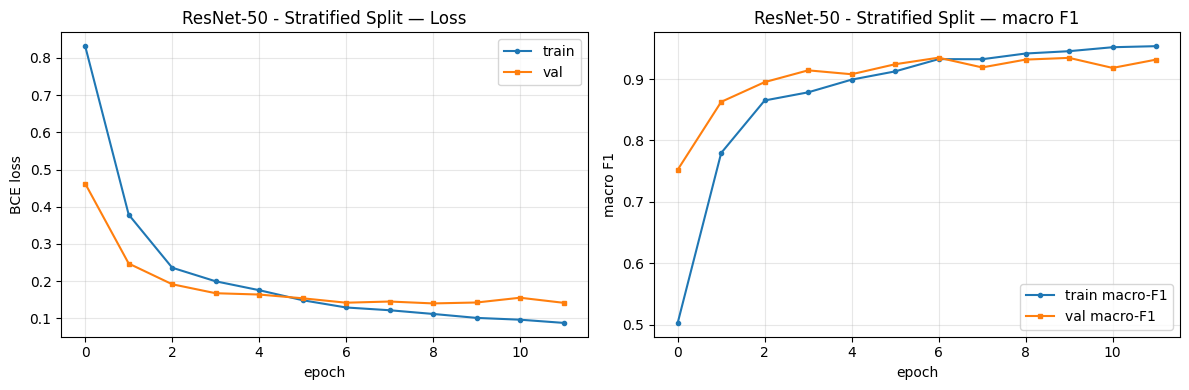

Saved training curves to: outputs/figures/resnetB_random_curves.png


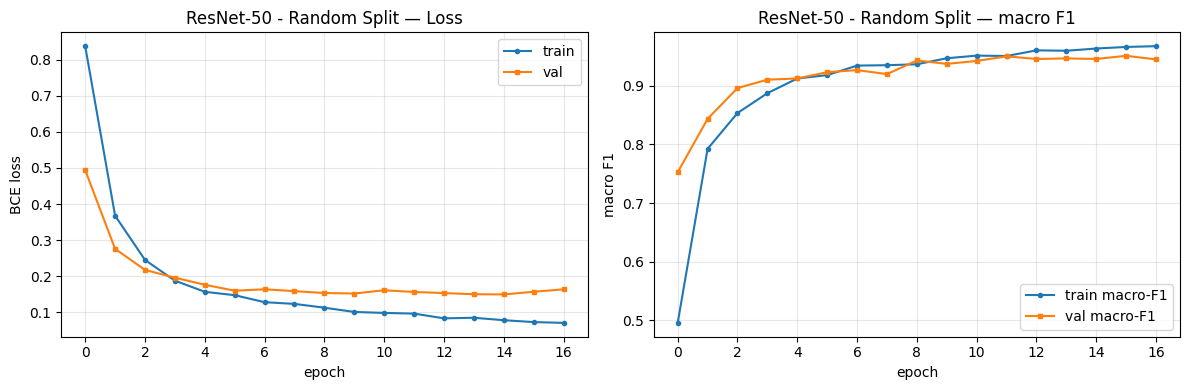

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'ResNet-50 - Random Split — Loss'}, xlabel='epoch', ylabel='BCE loss'>,
        <Axes: title={'center': 'ResNet-50 - Random Split — macro F1'}, xlabel='epoch', ylabel='macro F1'>],
       dtype=object))

In [23]:
plot_training_curves(
    logger_A,
    model_name = "ResNet-50 - Stratified Split",
    save_path  = "outputs/figures/resnetA_stratified_curves.png",
)

plot_training_curves(
    logger_B,
    model_name = "ResNet-50 - Random Split",
    save_path  = "outputs/figures/resnetB_random_curves.png",
)

## 13. Metricas per-class — F1 y AP por clase

Saved per-class metrics plot to: outputs/figures/resnetA_per_class.png


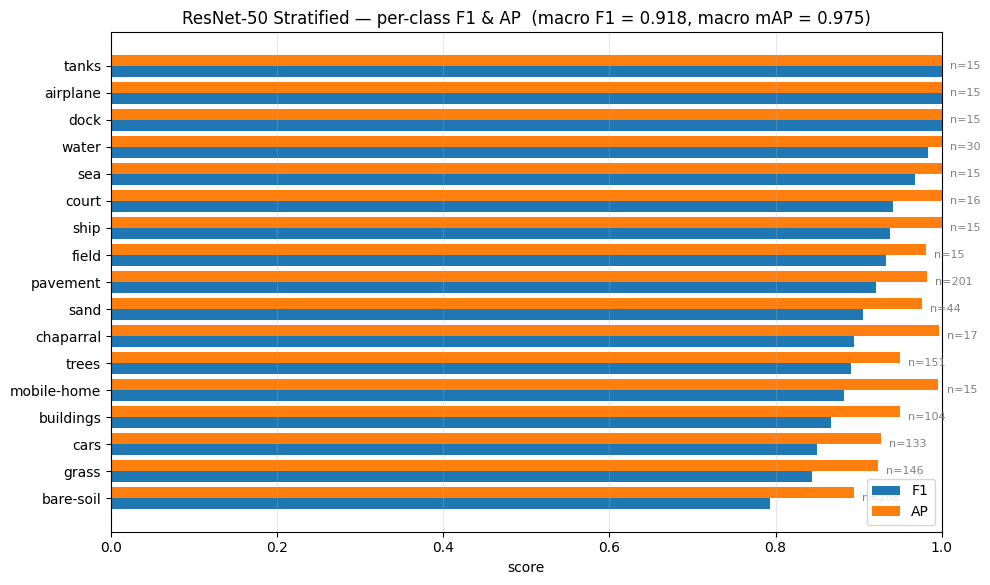


Per-class Summary:
      class  positives     F1     AP
  bare-soil        108 0.7934 0.8942
      grass        146 0.8435 0.9232
       cars        133 0.8503 0.9263
  buildings        104 0.8664 0.9494
mobile-home         15 0.8824 0.9958
      trees        151 0.8903 0.9497
  chaparral         17 0.8947 0.9967
       sand         44 0.9053 0.9761
   pavement        201 0.9204 0.9820
      field         15 0.9333 0.9810
       ship         15 0.9375 1.0000
      court         16 0.9412 1.0000
        sea         15 0.9677 1.0000
      water         30 0.9836 1.0000
       dock         15 1.0000 1.0000
   airplane         15 1.0000 1.0000
      tanks         15 1.0000 1.0000
Saved summary table to: outputs/resnetA_per_class.csv
Saved per-class metrics plot to: outputs/figures/resnetB_per_class.png


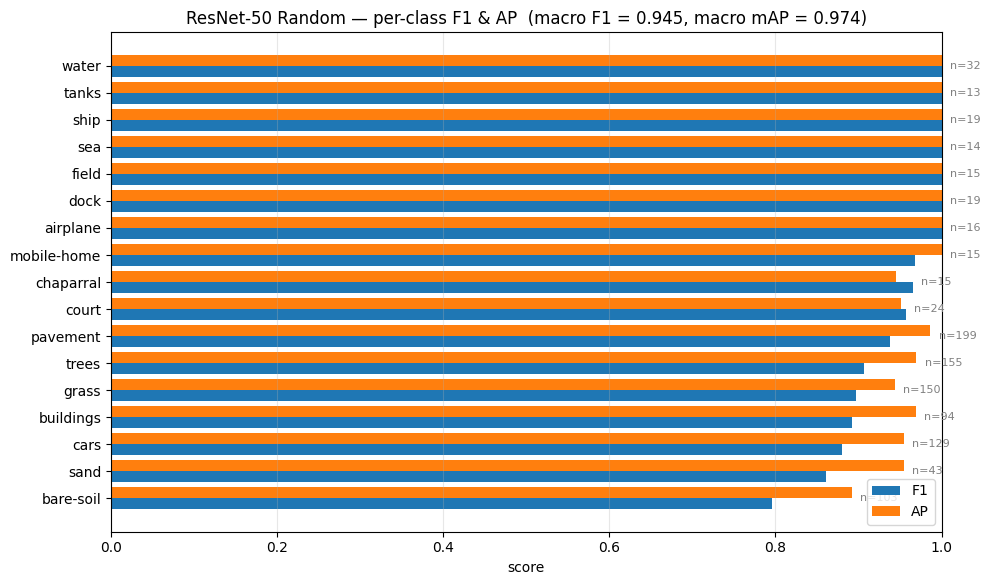


Per-class Summary:
      class  positives     F1     AP
  bare-soil        103 0.7962 0.8916
       sand         43 0.8602 0.9547
       cars        129 0.8797 0.9543
  buildings         94 0.8922 0.9688
      grass        150 0.8968 0.9436
      trees        155 0.9061 0.9694
   pavement        199 0.9380 0.9865
      court         24 0.9565 0.9516
  chaparral         15 0.9655 0.9452
mobile-home         15 0.9677 1.0000
   airplane         16 1.0000 1.0000
       dock         19 1.0000 1.0000
      field         15 1.0000 1.0000
        sea         14 1.0000 1.0000
       ship         19 1.0000 1.0000
      tanks         13 1.0000 1.0000
      water         32 1.0000 1.0000
Saved summary table to: outputs/resnetB_per_class.csv


(<Figure size 1000x595 with 1 Axes>,
 <Axes: title={'center': 'ResNet-50 Random — per-class F1 & AP  (macro F1 = 0.945, macro mAP = 0.974)'}, xlabel='score'>,
           class  positives      F1      AP
 0     bare-soil        103  0.7962  0.8916
 1          sand         43  0.8602  0.9547
 2          cars        129  0.8797  0.9543
 3     buildings         94  0.8922  0.9688
 4         grass        150  0.8968  0.9436
 5         trees        155  0.9061  0.9694
 6      pavement        199  0.9380  0.9865
 7         court         24  0.9565  0.9516
 8     chaparral         15  0.9655  0.9452
 9   mobile-home         15  0.9677  1.0000
 10     airplane         16  1.0000  1.0000
 11         dock         19  1.0000  1.0000
 12        field         15  1.0000  1.0000
 13          sea         14  1.0000  1.0000
 14         ship         19  1.0000  1.0000
 15        tanks         13  1.0000  1.0000
 16        water         32  1.0000  1.0000)

In [24]:
plot_per_class_metrics(
    labels_A, preds_A, probs_A, classes,
    macro_f1   = metrics_A["macro_f1"],
    macro_map  = metrics_A["macro_map"],
    model_name = "ResNet-50 Stratified",
    save_path  = "outputs/figures/resnetA_per_class.png",
    csv_output = "outputs/resnetA_per_class.csv",
)

plot_per_class_metrics(
    labels_B, preds_B, probs_B, classes,
    macro_f1   = metrics_B["macro_f1"],
    macro_map  = metrics_B["macro_map"],
    model_name = "ResNet-50 Random",
    save_path  = "outputs/figures/resnetB_per_class.png",
    csv_output = "outputs/resnetB_per_class.csv",
)

## 14. Guardar predicciones para analisis posterior

Guarda `preds`, `labels` y `probs` de ambos modelos en `outputs/predictions/` como archivos `.npz`.
De esta forma se pueden cargar en un script aparte sin necesidad de re-entrenar.

In [25]:
PRED_DIR = Path(PROJECT_DIR) / "outputs" / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

# Modelo A - Stratified
np.savez(
    str(PRED_DIR / "resnetA_stratified.npz"),
    preds   = preds_A,
    labels  = labels_A,
    probs   = probs_A,
    classes = np.array(classes),
)
print(f"Saved: {PRED_DIR / 'resnetA_stratified.npz'}")

# Modelo B - Random
np.savez(
    str(PRED_DIR / "resnetB_random.npz"),
    preds   = preds_B,
    labels  = labels_B,
    probs   = probs_B,
    classes = np.array(classes),
)
print(f"Saved: {PRED_DIR / 'resnetB_random.npz'}")

Saved: /content/drive/MyDrive/DL_Group_MGI1/outputs/predictions/resnetA_stratified.npz
Saved: /content/drive/MyDrive/DL_Group_MGI1/outputs/predictions/resnetB_random.npz


### Como cargar y graficar en un script aparte

Loaded A — preds: (314, 17), labels: (314, 17)
Loaded B — preds: (315, 17), labels: (315, 17)
Saved to: /content/drive/MyDrive/DL_Group_MGI1/outputs/figures/resnetA_em_by_classcount.png


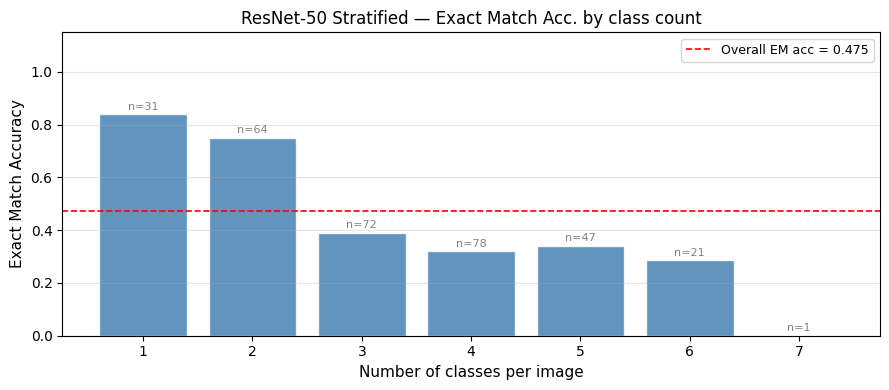

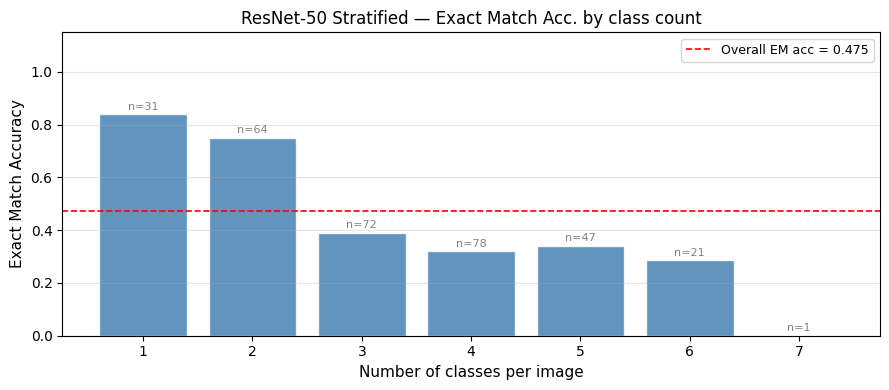

Saved to: /content/drive/MyDrive/DL_Group_MGI1/outputs/figures/resnetB_em_by_classcount.png


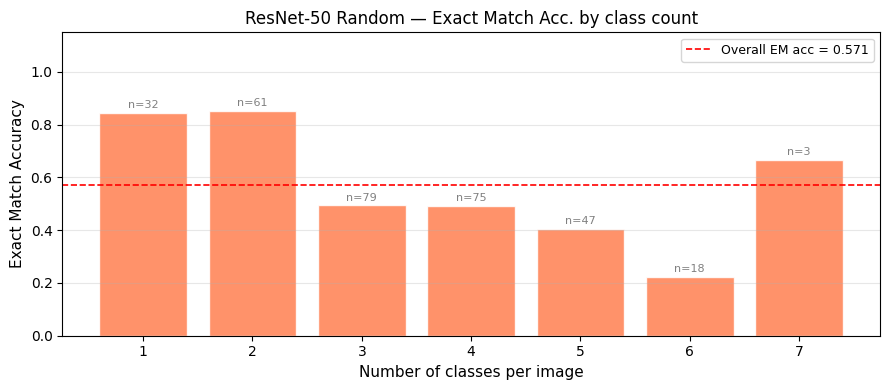

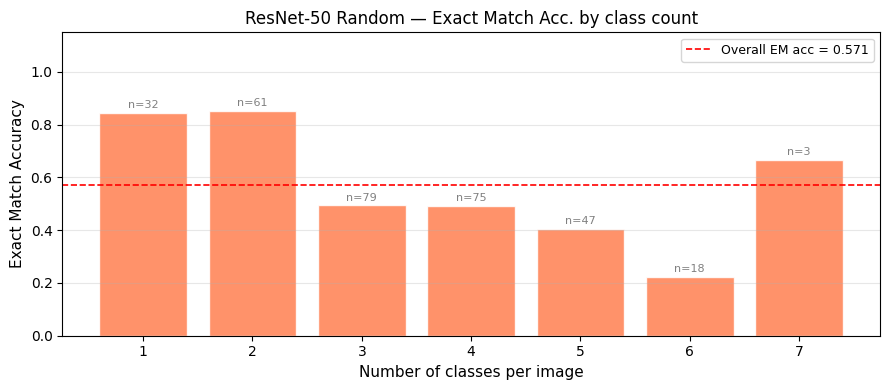

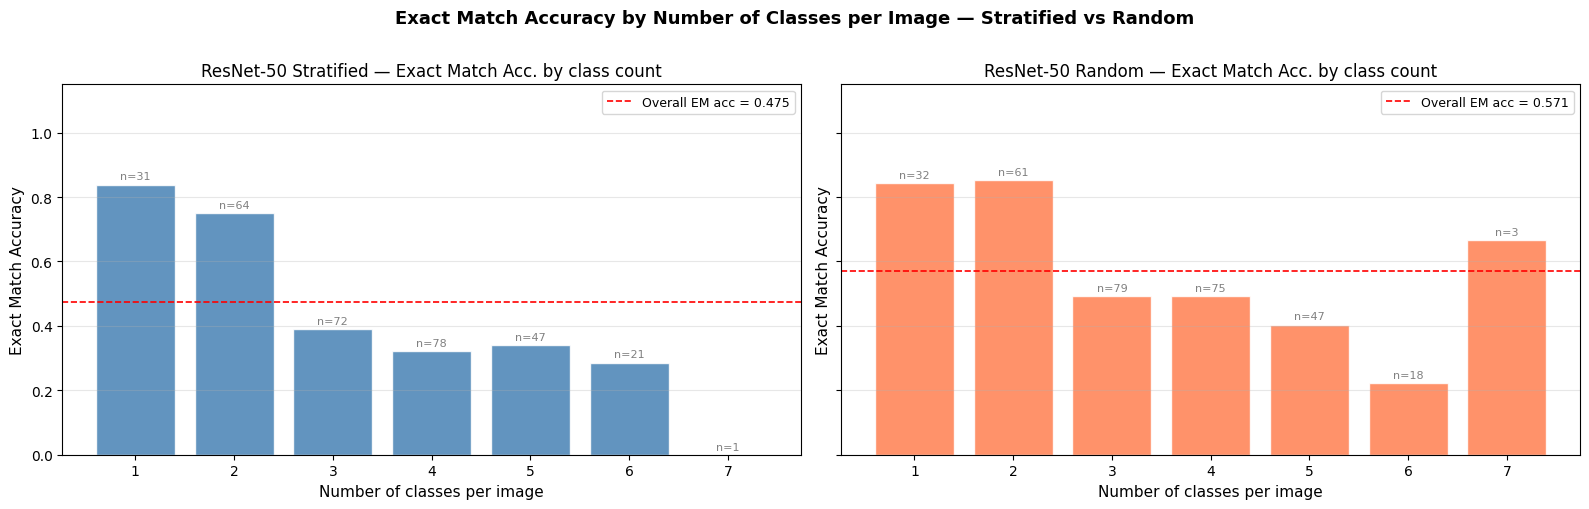

In [ ]:
import importlib
import utils
importlib.reload(utils)
from utils import plot_exact_match_by_class_count

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ── Cargar predicciones guardadas ─────────────────────────────────────────────
PRED_DIR = Path(PROJECT_DIR) / "outputs" / "predictions"

data_A = np.load(str(PRED_DIR / "vitA_stratified.npz"), allow_pickle=True)
data_B = np.load(str(PRED_DIR / "vitB_random.npz"),     allow_pickle=True)

preds_A_saved  = data_A["preds"]
labels_A_saved = data_A["labels"]
preds_B_saved  = data_B["preds"]
labels_B_saved = data_B["labels"]
classes_saved  = list(data_A["classes"])

print(f"Loaded A — preds: {preds_A_saved.shape}, labels: {labels_A_saved.shape}")
print(f"Loaded B — preds: {preds_B_saved.shape}, labels: {labels_B_saved.shape}")

# ── Plot comparativo side-by-side ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

plot_exact_match_by_class_count(
    preds_A_saved, labels_A_saved,
    model_name = "ViT-B/16 Stratified",
    color      = "steelblue",
    ax         = axes[0],
)
plot_exact_match_by_class_count(
    preds_B_saved, labels_B_saved,
    model_name = "ViT-B/16 Random",
    color      = "coral",
    ax         = axes[1],
)

fig.suptitle("Exact Match Accuracy by Number of Classes per Image — Stratified vs Random",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(
    str(Path(PROJECT_DIR) / "outputs/figures/vit_em_by_classcount_comparison.png"),
    dpi=150, bbox_inches="tight"
)
display(fig)
plt.close(fig)

In [ ]:
from utils import plot_prediction_grid
fig_B = plot_prediction_grid(
    test_preds=preds_B,
    test_labels=labels_B,
    test_probs=probs_B,
    classes=classes,
    test_loader=test_loader_B,
    root_dir="ucmdata",
    label_file="LandUse_Multilabeled.txt",
    n_show=9,
    seed=4,
    save_path="outputs/figures/ResNet50_random_predictions_grid.png"
)

## 15. Referencias

- He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep residual learning for image recognition*. IEEE CVPR 2016.
- Yang, Y., & Newsam, S. (2010). *Bag-of-visual-words and spatial extensions for land-use classification*. ACM SIGSPATIAL.
- UCMerced Land Use Dataset: http://weegee.vision.ucmerced.edu/datasets/landuse.html